## 과제: 100개의 임의 점 좌표에 대해 5-최근접 이웃 구하기 및 시각화

### 과제 설명
1. 목표: 100개의 임의의 2차원 좌표에 대해 각 점의 5-최근접 이웃을 찾아 시각화하는 프로그램을 작성.

2. 조건:
거리: 유클리드 거리 제곱을 사용하여 각 점 간의 거리를 계산.
출력: 각 점에 대해 가장 가까운 5개의 이웃 좌표를 출력.
시각화: 각 좌표와 해당 좌표에 가까운 5개의 이웃을 스캐터 플롯으로 시각화. (점마다 이웃 관계를 선으로 연결하여 표시)


### 3. 단계별 요구 사항









### 3.1 난수 좌표 생성:
[0, 1) 범위에서 100개의 2차원 좌표를 생성.

In [19]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn; seaborn.set()

rand = np.random.RandomState(100)

X = rand.rand(10, 2)

### 3.2 거리 행렬 계산:
각 점 간의 유클리드 거리 제곱을 계산하여 100x100 크기의 거리 행렬을 생성.

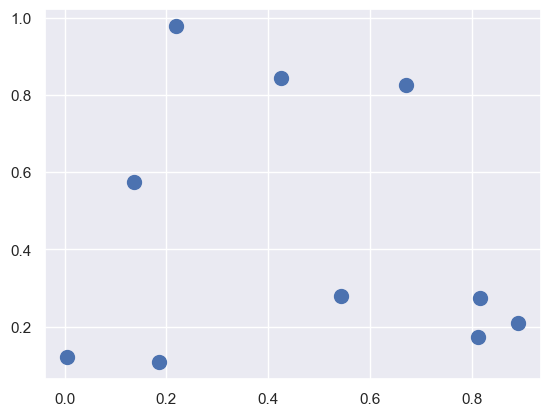

In [20]:

plt.scatter(X[:, 0], X[:, 1], s=100);
dist_sq = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) **2, axis=-1)

### 3.3 '5-최근접' 이웃 찾기:
각 점에 대해 가장 가까운 5개의 점을 거리 순으로 정렬.
자기 자신을 제외하고 가장 가까운 5개의 이웃.

In [21]:
dist_sq.diagonal()

nearest = np.argsort(dist_sq, axis=1)
print(nearest)



[[0 9 8 5 6 4 2 3 1 7]
 [1 7 3 4 0 9 6 8 5 2]
 [2 6 4 0 8 9 1 7 5 3]
 [3 1 7 0 9 4 5 8 6 2]
 [4 1 7 6 2 0 3 9 8 5]
 [5 8 9 0 3 6 1 4 2 7]
 [6 2 0 4 8 9 5 1 3 7]
 [7 1 4 3 0 6 2 9 8 5]
 [8 5 9 0 6 3 1 4 2 7]
 [9 5 8 0 3 6 1 4 2 7]]


### 3.4 결과 출력:
각 점에 대해 가장 가까운 5개의 이웃의 좌표와 거리 제곱을 출력.


In [22]:
K = 5
nearest_partition = np.argpartition(dist_sq, K + 1, axis=1)


### 3.5 시각화:
matplotlib를 사용하여 각 점과 해당 점의 5-최근접 이웃을 플롯.
각 점은 scatter로 표시하고, 가까운 이웃과 연결하는 선을 추가하여 관계를 시각적으로 표현.

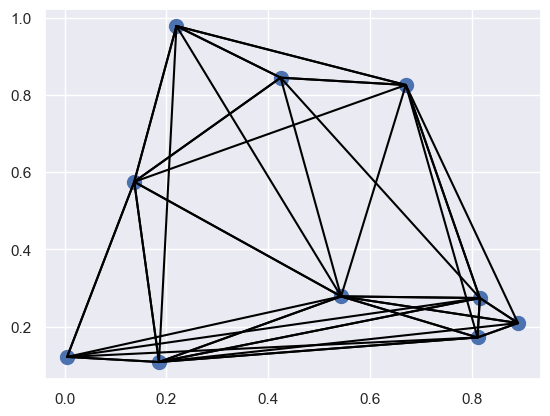

In [23]:
plt.scatter(X[:, 0], X[:, 1], s=100)

K = 5
for i in range(X.shape[0]):
    for j in nearest_partition[i, :K+1]:
        plt.plot(*zip(X[j], X[i]), color='black')